In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/delivery_data_features.csv")

print(df.shape)

(142502, 41)


In [3]:
df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,destination_hub_volume,corridor_avg_actual_time,corridor_avg_osrm_time,corridor_avg_distance,historical_corridor_delay,historical_delay_ratio,trip_segments,trip_total_distance,trip_total_actual_time,trip_avg_speed
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,54,43.574074,27.685185,32.264602,15.888889,1.573913,10,102.7106,167.0,36.902012
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,54,43.574074,27.685185,32.264602,15.888889,1.573913,10,102.7106,167.0,36.902012
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,54,43.574074,27.685185,32.264602,15.888889,1.573913,10,102.7106,167.0,36.902012
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,54,43.574074,27.685185,32.264602,15.888889,1.573913,10,102.7106,167.0,36.902012
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,54,43.574074,27.685185,32.264602,15.888889,1.573913,10,102.7106,167.0,36.902012


In [4]:
df["route_type"].value_counts()

route_type
FTL        98827
Carting    43675
Name: count, dtype: int64

In [5]:
route_summary = (
    df.groupby("route_type")
    .agg(
        shipments=("trip_uuid", "count"),
        avg_actual_time=("actual_time", "mean"),
        avg_osrm_time=("osrm_time", "mean"),
        avg_distance=("actual_distance_to_destination", "mean"),
        avg_speed=("trip_avg_speed", "mean"),
        avg_delay_ratio=("historical_delay_ratio", "mean")
    )
    .round(2)
)

route_summary

,shipments,avg_actual_time,avg_osrm_time,avg_distance,avg_speed,avg_delay_ratio
route_type,,,,,,
Carting,43675,70.37,30.47,26.63,35.00,2.45
FTL,98827,576.34,298.34,329.59,43.16,2.00


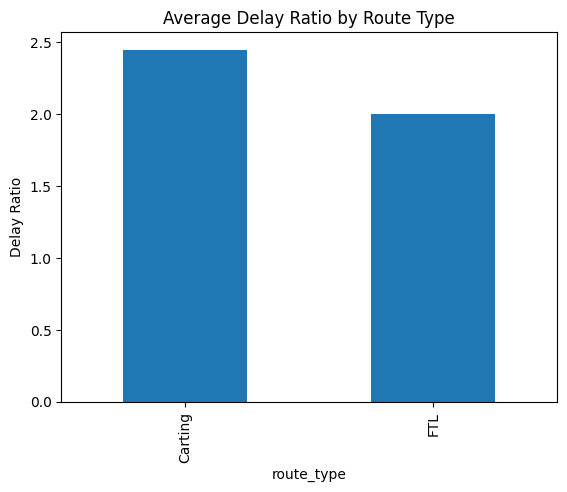

In [6]:
import matplotlib.pyplot as plt

route_summary["avg_delay_ratio"].plot(
    kind="bar"
)

plt.title("Average Delay Ratio by Route Type")
plt.ylabel("Delay Ratio")
plt.show()

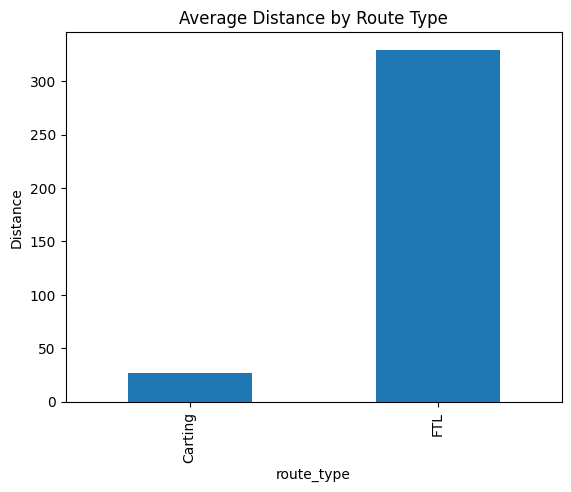

In [7]:
route_summary["avg_distance"].plot(
    kind="bar"
)

plt.title("Average Distance by Route Type")
plt.ylabel("Distance")
plt.show()

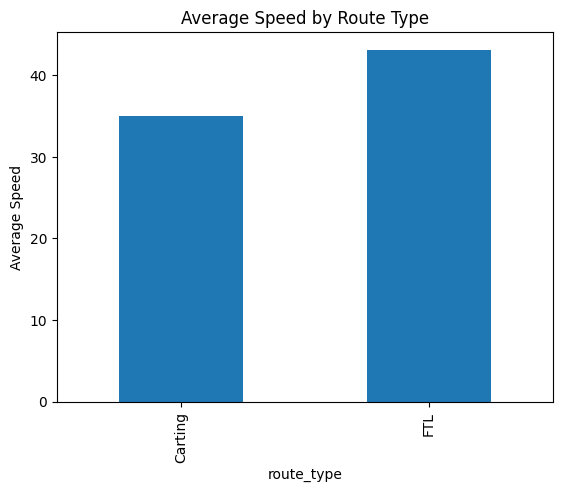

In [8]:
route_summary["avg_speed"].plot(
    kind="bar"
)

plt.title("Average Speed by Route Type")
plt.ylabel("Average Speed")
plt.show()

In [9]:
corridor_route = (
    df.groupby(["corridor", "route_type"])
    .agg(
        shipments=("trip_uuid", "count"),
        avg_actual_time=("actual_time", "mean"),
        avg_distance=("actual_distance_to_destination", "mean"),
        avg_delay_ratio=("historical_delay_ratio", "mean")
    )
    .reset_index()
)

corridor_route.head()

,corridor,route_type,shipments,avg_actual_time,avg_distance,avg_delay_ratio
0,IND000000AAL->IND411033AAA,Carting,35,60.457143,13.641024,2.776903
1,IND000000AAQ->IND700028AAB,Carting,4,78.250000,10.295014,6.260000
2,IND000000AAS->IND783370AAC,FTL,18,50.555556,26.000435,1.952790
3,IND000000AAZ->IND444203AAA,FTL,3,181.666667,42.244027,4.823009
4,IND000000AAZ->IND444303AAA,FTL,2,103.500000,34.761041,3.285714


In [10]:
def recommend_route(distance, delay_ratio):

    if distance > 300 and delay_ratio < 1.2:
        return "FTL"

    elif distance < 100:
        return "Carting"

    elif delay_ratio > 1.5:
        return "FTL"

    else:
        return "Carting"

In [11]:
df["recommended_route"] = df.apply(
    lambda x: recommend_route(
        x["actual_distance_to_destination"],
        x["historical_delay_ratio"]
    ),
    axis=1
)

df[
    ["route_type", "recommended_route"]
].head()

,route_type,recommended_route
0,Carting,Carting
1,Carting,Carting
2,Carting,Carting
3,Carting,Carting
4,Carting,Carting


In [12]:
df["recommended_route"].value_counts()

recommended_route
Carting    84095
FTL        58407
Name: count, dtype: int64

In [13]:
agreement = (
    df["route_type"]
    == df["recommended_route"]
).mean()

print(
    f"Agreement Rate: {agreement:.2%}"
)

Agreement Rate: 70.95%


In [14]:
df.groupby("route_type")[
    "actual_distance_to_destination"
].describe()

,count,mean,std,min,25%,50%,75%,max
route_type,,,,,,,,
Carting,43675.0,26.632771,20.633607,9.000045,10.647438,19.329675,35.832145,234.864906
FTL,98827.0,329.592015,380.243390,15.000648,45.800218,154.821071,494.439991,1927.447705


In [15]:
delay_analysis = (
    df.groupby("route_type")
    .agg(
        avg_delay_ratio=("historical_delay_ratio", "mean"),
        avg_actual_time=("actual_time", "mean"),
        avg_osrm_time=("osrm_time", "mean")
    )
    .round(2)
)

delay_analysis

,avg_delay_ratio,avg_actual_time,avg_osrm_time
route_type,,,
Carting,2.45,70.37,30.47
FTL,2.00,576.34,298.34


In [18]:
ftl_carting_summary = route_summary.copy()

ftl_carting_summary.to_csv(
    "../reports/ftl_vs_carting_summary.csv"
)

In [19]:
decision_framework = pd.DataFrame({
    "Condition": [
        "Distance < 50 km",
        "Distance > 150 km",
        "High Volume Corridor",
        "Urban Distribution",
        "Long Haul Transport",
        "Last Mile Delivery"
    ],
    "Recommended_Mode": [
        "Carting",
        "FTL",
        "FTL",
        "Carting",
        "FTL",
        "Carting"
    ]
})

decision_framework

,Condition,Recommended_Mode
0,Distance < 50 km,Carting
1,Distance > 150 km,FTL
2,High Volume Corridor,FTL
3,Urban Distribution,Carting
4,Long Haul Transport,FTL
5,Last Mile Delivery,Carting


In [20]:
decision_framework.to_csv(
    "../reports/ftl_carting_decision_framework.csv",
    index=False
)

## FTL vs Carting Decision Framework

A comparative analysis of transportation modes was conducted using shipment distance, travel time, and historical delay characteristics.

### Key Findings

FTL shipments covered significantly larger distances (average 329.6 km) while maintaining a lower average delay ratio (2.00) compared to Carting shipments (average 26.6 km distance and delay ratio 2.45).

The results indicate that FTL operations are more suitable for long-haul transportation corridors, whereas Carting operations are better suited for local and last-mile distribution despite experiencing relatively higher delays.

### Recommended Decision Framework

| Corridor Characteristics         | Recommended Mode |
| -------------------------------- | ---------------- |
| Distance < 50 km                 | Carting          |
| Distance > 150 km                | FTL              |
| High-volume inter-city corridors | FTL              |
| Urban distribution routes        | Carting          |
| Long-haul transportation         | FTL              |
| Last-mile delivery operations    | Carting          |

### Business Implications

Implementing a route-selection framework based on corridor characteristics can improve transportation efficiency, reduce operational delays, and support better ETA reliability.

FTL should be prioritized for long-distance and high-volume corridors, while Carting should be reserved for local distribution and final-mile delivery operations.

This framework can serve as a decision-support tool for transportation planning and network optimization.
